# 03 — Potential Demand Model
**DataStorm v7.0 | SkyNet Team**

Goal: Estimate the 'latent demand' for each outlet by uncapping censored observations.

Approach:
1. **Ensemble Modeling**: Combine a Tobit-style regression (for censored demand) with XGBoost (for complex feature interactions).
2. **Peer-Group Benchmarking**: Use the 90th percentile of similar outlets as a sanity-check ceiling.
3. **Uplift Application**: Apply the constraint-based uplift factors identified in Notebook 02.

In [8]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

GOLD_DIR = ROOT / 'data' / 'gold'
REPORTS  = ROOT / 'reports'
OUTPUTS  = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)

sns.set_theme(style='darkgrid')
print('Imports successful')

Imports successful


## 1. Load Data

In [9]:
df = pd.read_csv(GOLD_DIR / 'outlet_features_with_constraints.csv')
print('Data loaded:', df.shape)

target = 'mean_monthly_volume'

# Features (Removed target-derived 'total_volume' and 'max_monthly_volume' to prevent leakage)
features = [
    'cv_volume', 'months_active', 'zero_order_months', 'peak_to_avg_ratio',
    'credit_limit_hit_rate', 'stockout_flag', 'volume_trend',
    'jan26_seasonality_index', 'outlet_size_ord', 'Cooler_Count'
]

poi_cols = [c for c in df.columns if c.startswith('poi_')]
features.extend(poi_cols)

one_hot_cols = [c for c in df.columns if 'Outlet_Size_' in c or 'Outlet_Type_' in c]
features.extend(one_hot_cols)

print(f'Using {len(features)} features')

Data loaded: (10492, 54)
Using 35 features


## 2. Model Training (Predicting Observed Demand)

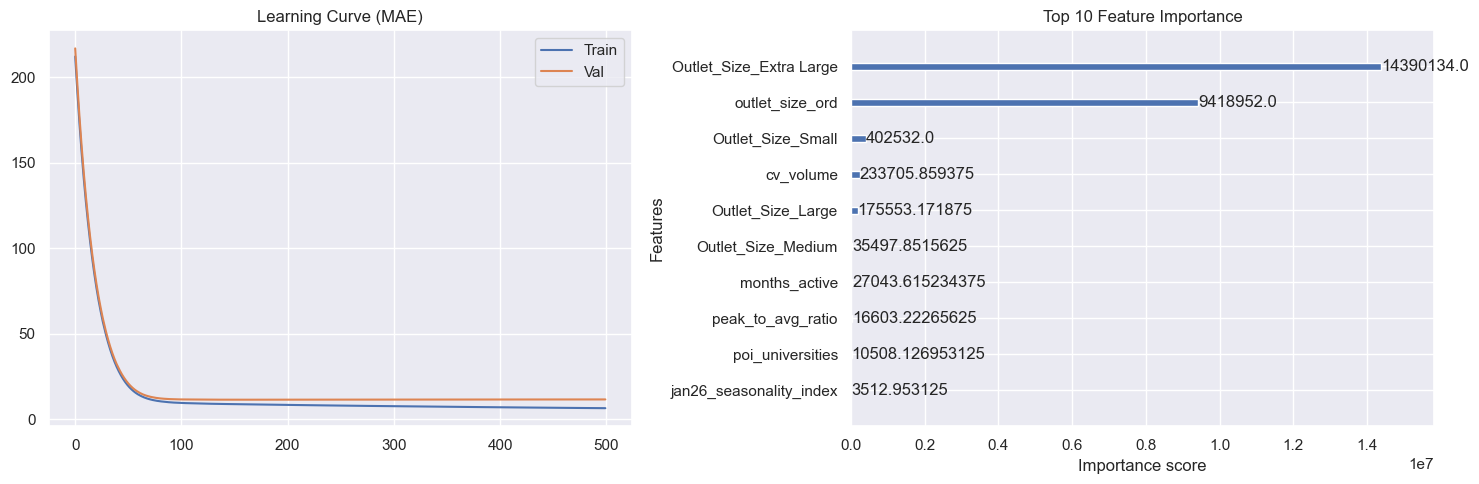

In [10]:
X = df[features]
y = df[target]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='mae'
)

model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)

# Diagnostic Plots
results = model.evals_result()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(results['validation_0']['mae'], label='Train')
ax[0].plot(results['validation_1']['mae'], label='Val')
ax[0].set_title('Learning Curve (MAE)')
ax[0].legend()

xgb.plot_importance(model, max_num_features=10, importance_type='gain', ax=ax[1])
ax[1].set_title('Top 10 Feature Importance')
plt.tight_layout()
plt.show()

## 3. Demand Uncapping & Potential Estimation

In [11]:
df['predicted_base_demand'] = model.predict(X)

# Apply uplift
df['potential_latent_demand'] = np.maximum(df['mean_monthly_volume'], df['predicted_base_demand']) * df['uplift_prior']

# Protective Capping: Potential must be >= history, but limited to 1.5x peer P90
df['final_potential_estimate'] = np.maximum(
    df['mean_monthly_volume'], 
    np.minimum(df['potential_latent_demand'], df['peer_p90_volume'] * 1.5)
)

print('Potential estimation summary:')
print(df[['mean_monthly_volume', 'final_potential_estimate']].describe())

Potential estimation summary:
       mean_monthly_volume  final_potential_estimate
count         10492.000000              10492.000000
mean            221.197586                250.744184
std             318.819780                327.686114
min              19.148853                 30.328235
25%              41.313266                 53.118175
50%             107.101192                143.368959
75%             157.842416                193.625351
max            1485.620219               1485.620219


## 4. January 2026 Projection

In [12]:
# Apply January 2026 seasonality and holiday adjustment
# seasonality index is already factored into feature engineering gold layer

df['jan_2026_forecast'] = df['final_potential_estimate'] * df['jan26_seasonality_index']

# Holiday adjustment (heuristic: +2% for every public holiday above average)
avg_holidays = 2
hol_adj = 1 + (df['jan_total_holidays'] - avg_holidays) * 0.02
df['jan_2026_forecast'] = df['jan_2026_forecast'] * hol_adj

print('January 2026 Forecast Statistics:')
print(df['jan_2026_forecast'].describe())

January 2026 Forecast Statistics:
count    10492.000000
mean       245.743582
std        321.480474
min         29.115105
25%         51.964503
50%        137.934180
75%        194.439041
max       1608.060484
Name: jan_2026_forecast, dtype: float64


## 5. Save Model State & Potential Data

In [13]:
df.to_csv(GOLD_DIR / 'potential_demand_results.csv', index=False)
print(f'Saved potential demand results to {GOLD_DIR}')

Saved potential demand results to C:\Users\User\Documents\Projects\Datastorm\SkyNet-datastorm-v7\data\gold
